# 03 - Fitness Function Development

## Objective

The Genetic Algorithm requires a scalar objective function to compare PID controllers.

This notebook evaluates the proposed multi-objective fitness function and analyzes how different PID gains influence system performance.

The objectives considered are:

- Tracking Error (Integral Absolute Error)
- Overshoot
- Settling Time
- Control Effort

Lower fitness values indicate better controller performance.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

In [2]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd

from src.simulator import LinearDeltaModel
from src.features import extract_features
from src.fitness import FitnessEvaluator

plt.style.use("seaborn-v0_8-darkgrid")

## Initialize Framework

In [3]:
simulator = LinearDeltaModel()

fitness = FitnessEvaluator()

## Reference PID Controller

In [4]:
trajectory = simulator.run(
    kp=1.5,
    ki=0.2,
    kd=0.4
)

## Extract Performance Features

In [5]:
features = extract_features(trajectory)

features

FeatureVector(iae=7.765199827006234, overshoot=0.0, settling_time=1.49, control_effort=934.0274609477625, is_stable=True)

## Compute Fitness Score

In [6]:
score = fitness.evaluate(trajectory)

print(f"Fitness = {score:.6f}")

Fitness = 0.550909


## Fitness Breakdown

In [7]:
fitness.breakdown(trajectory)

{'iae': 7.7652,
 'overshoot': 0.0,
 'settling_time': 1.49,
 'control_effort': 934.0275,
 'weighted_score': 0.550909,
 'crashed': False}

## Compare Multiple PID Controllers

In [8]:
tests = [

    # Label              Kp    Ki    Kd
    ("Pure P",           1.0,  0.0,  0.0),   # No damping, will oscillate
    ("Pure PD",          1.5,  0.0,  0.8),   # Good damping, no steady-state correction
    ("Pure PI",          1.5,  0.5,  0.0),   # Slow, may overshoot
    ("Underdamped",      4.0,  0.5,  0.1),   # Too aggressive, likely oscillates
    ("Overdamped",       0.3,  0.0,  0.5),   # Too slow, never settles fast enough
    ("Unstable",         5.0,  2.0,  0.0),   # Expected to crash
    ("Near Optimal",     1.5,  0.2,  0.4),   # Balanced — expected best score
    ("High Derivative",  1.5,  0.1,  2.5),   # Heavy damping, high control effort
]

In [9]:
results = []

for label, kp, ki, kd in tests:

    tr = simulator.run(kp, ki, kd)

    fv = extract_features(tr)

    score = fitness.evaluate(tr)

    results.append({

        "Label":    label,
        "Kp":       kp,
        "Ki":       ki,
        "Kd":       kd,
        "Fitness":  score,
        "IAE":      round(fv.iae, 4),
        "Overshoot":round(fv.overshoot, 4),
        "Settling": round(fv.settling_time, 4),
        "Effort":   round(fv.control_effort, 4),
        "Crashed":  not fv.is_stable

    })

results = pd.DataFrame(results)

results

,Label,Kp,Ki,Kd,Fitness,IAE,Overshoot,Settling,Effort,Crashed
0,Pure P,1.0,0.0,0.0,0.475156,8.1540,0.0,1.49,46.8913,False
1,Pure PD,1.5,0.0,0.8,0.552274,7.6082,0.0,1.49,3305.8682,False
2,Pure PI,1.5,0.5,0.0,0.478338,7.9143,0.0,1.49,158.6097,False
3,Underdamped,4.0,0.5,0.1,0.513737,7.0798,0.0,1.49,790.7719,False
4,Overdamped,0.3,0.0,0.5,0.569812,8.1343,0.0,1.49,1240.6201,False
5,Unstable,5.0,2.0,0.0,0.511298,6.6190,0.0,1.43,1469.1957,False
6,Near Optimal,1.5,0.2,0.4,0.550909,7.7652,0.0,1.49,934.0275,False
7,High Derivative,1.5,0.1,2.5,0.528340,6.8902,0.0,1.49,30998.3915,False


## Fitness Comparison

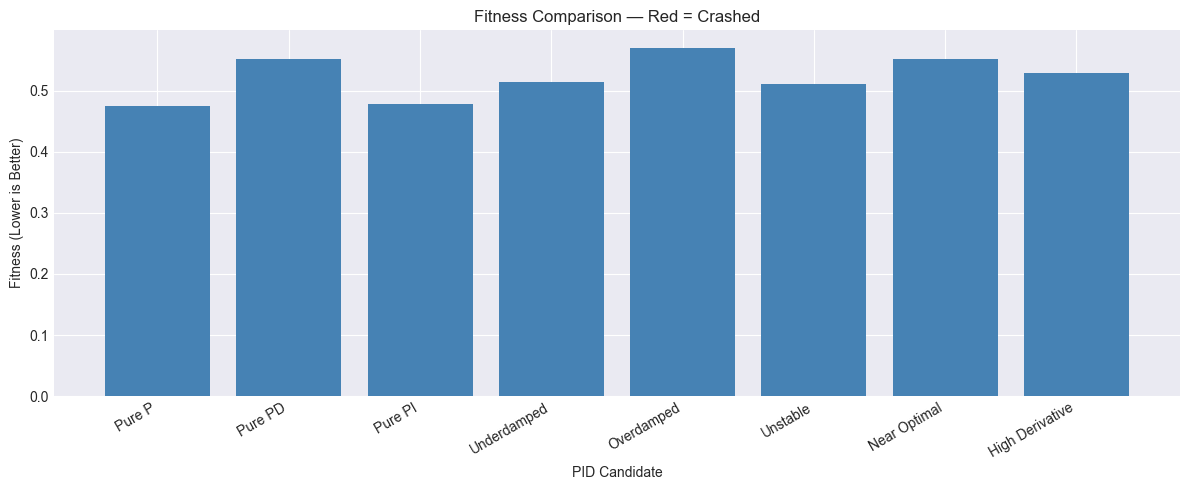

In [10]:
plt.figure(figsize=(12,5))

colors = ["red" if c else "steelblue" for c in results["Crashed"]]

plt.bar(
    results["Label"],
    results["Fitness"],
    color=colors
)

plt.xticks(rotation=30, ha="right")

plt.xlabel("PID Candidate")

plt.ylabel("Fitness (Lower is Better)")

plt.title("Fitness Comparison — Red = Crashed")

plt.tight_layout()

plt.show()

## Controller Responses

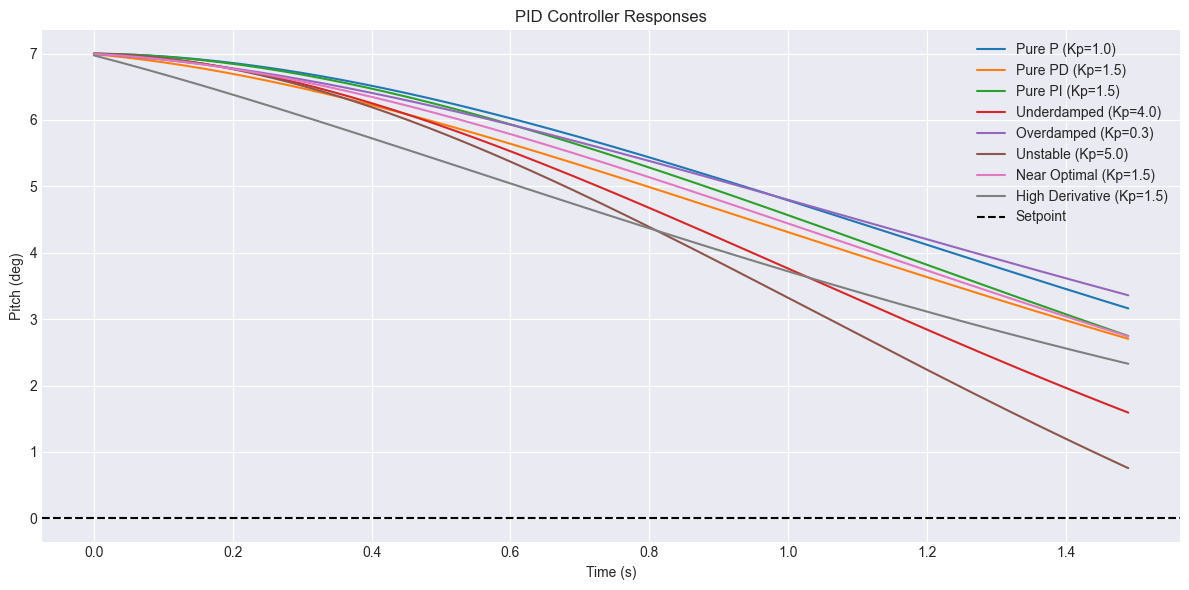

In [11]:
plt.figure(figsize=(12,6))

for label, kp, ki, kd in tests:

    tr = simulator.run(kp, ki, kd)

    plt.plot(
        tr.time,
        tr.pitch,
        label=f"{label} (Kp={kp})"
    )

plt.axhline(0, linestyle="--", color="black", label="Setpoint")

plt.xlabel("Time (s)")

plt.ylabel("Pitch (deg)")

plt.title("PID Controller Responses")

plt.legend(loc="upper right")

plt.tight_layout()

plt.show()

## Discussion

The fitness function combines multiple control objectives into a single optimization criterion.

Rather than minimizing only tracking error, it also discourages excessive overshoot, long settling times, and aggressive control actions.

This produces controllers that are both stable and practically usable.

# Conclusion

The proposed fitness function provides a balanced evaluation of controller performance and serves as the objective function for the Genetic Algorithm developed in the next notebook.